# Exercise: Design Multiple Experiments in Pyomo.DoE

In this exercise notebook, you will use the reparameterized tc lab model which you used in the previous [parmest exercise]((../notebooks/parmest_exercise.ipynb)) and design two experiments using `Pyomo.DoE`. The structure of the reformulated model is:
$$
\frac{dT_H}{dt} = \beta_1 (T_{\text{amb}} - T_H) + \beta_2 (T_S - T_H) + \beta_4 u(t),
$$

$$
\frac{dT_S}{dt} = \beta_3 (T_H - T_S)
$$

where
$$
\beta_1 = \frac{U_a}{C_p^H}, \quad
\beta_2 = \frac{U_b}{C_p^H}, \quad
\beta_3 = \frac{U_b}{C_p^S}, \quad
\beta_4 = \frac{\alpha P}{C_p^H}
$$

You will use `D-optimality` (determinant of the FIM) to design the two experiments.

Import necessary functions for the two-state TC Lab model

In [1]:
import sys

# If running on Google Colab, install Pyomo and Ipopt via IDAES
on_colab = "google.colab" in sys.modules
if on_colab:
    !wget "https://raw.githubusercontent.com/dowlinglab/pyomo-doe/main/notebooks/tclab_pyomo.py"
else:
    import os

    if "exercise_solutions" in os.getcwd():
        # Add the "notebooks" folder to the path
        # This is needed for running the solutions from a separate folder
        # You only need this if you run locally
        sys.path.append('../notebooks')

# import TCLab model, simulation, and data analysis functions
from tclab_pyomo import (
    TC_Lab_data,
    TC_Lab_experiment,
    extract_plot_results,
    results_summary,
)

# set default number of states in the TCLab model
number_tclab_states = 2

## Load experimental data (sine test)
We will load the sine test experimental data to serve as an initial point. 

In [2]:
import pandas as pd

if on_colab:
    file = "https://raw.githubusercontent.com/dowlinglab/pyomo-doe/main/data/tclab_sine_test_5min_period.csv"
else:
    file = '../data/tclab_sine_test_5min_period.csv'
df = pd.read_csv(file)
df.head()

,Time,T1,T2,Q1,Q2
0,0.00,22.2,22.2,50,0
1,1.01,22.2,22.2,51,0
2,2.01,22.2,22.2,52,0
3,3.00,22.2,22.2,53,0
4,4.01,22.2,22.2,54,0


## Use prior parameter information
We will use the parameter estimates and covariance matrix obtained in the previous notebook. Since the Fisher information matrix (FIM) is the inverse of the covariance matrix, we can use that result as prior information for the new design problem.

In [3]:
import numpy as np
# Load Pyomo.DoE class
from pyomo.contrib.doe import DesignOfExperiments
from pyomo.environ import SolverFactory

# Theta values estimated from the regularized regresssion in the previous notebook
# L2 regularization
theta_values = {
    'beta_1': 0.0133,  # Watts/Joules
    'beta_2': 0.0216,  # Watts/Joules
    'beta_3': 0.0287,  # Watts/Joules
    'beta_4': 0.0102,  # °C.Watts/(Joules.%)
}

# Create a new experiemnt object for design of experiments, using the same data and
# theta values as before
# Here, we will induce a step size of 6 seconds, as to make the optimization problem
# more tractable

skip = 15

# Create the data object considering the new control points every 60 seconds
tc_data_1 = TC_Lab_data(
    name="Sine Wave Test for Heater 1",
    time=df['Time'].values[::skip],
    T1=df['T1'].values[::skip],
    u1=df['Q1'].values[::skip],
    P1=200,
    TS1_data=None,
    T2=df['T2'].values[::skip],
    u2=df['Q2'].values[::skip],
    P2=200,
    TS2_data=None,
    Tamb=df['T1'].values[0],
)
# Create experiment object for design of experiments
doe_experiment_1 = TC_Lab_experiment(
    data=tc_data_1,
    theta_initial=theta_values,
    number_of_states=number_tclab_states,
    reparam=True,
)
doe_exp1 = DesignOfExperiments(experiment=doe_experiment_1)
PRIOR_FIM = doe_exp1.compute_FIM()
results_summary(PRIOR_FIM)

======Results Summary======
Five design criteria log10() value:
Pseudo A-optimality: 10.197162337522665
A-optimality: 5.4553379440727205
D-optimality: 19.3836680581383
E-optimality: -5.480870473356719
Modified E-optimality: 15.622563501113394

FIM:
 [[ 4.79223296e+09  1.74744312e+08 -1.73533819e+08 -7.00079719e+09]
 [ 1.74744312e+08  2.76967611e+07 -3.52947724e+07 -3.68979213e+08]
 [-1.73533819e+08 -3.52947724e+07  5.08690093e+07  4.22693967e+08]
 [-7.00079719e+09 -3.68979213e+08  4.22693967e+08  1.08749145e+10]]

eigenvalues:
 [1.54901235e+10 2.53834205e+08 3.30468087e-06 1.75550058e+06]

Eigenvector matrix:
          eigvec_1  eigvec_2  eigvec_3  eigvec_4
Ua        -0.5478    0.7534   -0.3631    0.0235
Ub        -0.0262   -0.2489   -0.4204    0.8721
inv_CpH    0.0291    0.3835    0.7835    0.4880
inv_CpS    0.8357    0.4727   -0.2785    0.0258


In [4]:
from pyomo.contrib.doe.utils import rescale_FIM

theta_ref = np.array(
    [
        theta_values["beta_1"],
        theta_values["beta_2"],
        theta_values["beta_3"],
        theta_values["beta_4"],
    ]
)
# Because the parameter values are very small, we can use parameter
# scaling in DesignOfExperiments to improve numerical conditioning.
SCALE_BY_NOMINAL_PARAM = True
# Set to True if you want to scale the FIM by the nominal parameter values
SCALE_PRIOR = True  # Set to True if you want to scale the prior FIM

if SCALE_PRIOR and SCALE_BY_NOMINAL_PARAM:
    FIM_scaled = rescale_FIM(PRIOR_FIM, theta_ref)
else:
    FIM_scaled = PRIOR_FIM

## Initialize two experiments
We now create two experiment objects. The first uses the measured sine-test data, and the second uses a different initial input profile so that the optimizer can optimize both experiments simultaneously.

In [5]:
from dataclasses import replace
# Set a random seed for reproducibility
SEED: int = 11 # Choose any integer seed you like
PDF = "uniform" # Choose between "normal" or "uniform" distribution for the new design of u1


def get_initial_u1_design(PDF="uniform", seed=11, sample_data = tc_data_1):
    rng = np.random.default_rng(seed=seed)
    if PDF == "normal":
        u1_design = rng.normal(loc=50.0, scale=10.0, size=len(sample_data.time))
        # Normal distribution is unbounded, so we need to clip the values to be within the 
        # bounds of the control input, which is [0, 100] in this case.
        u1_design = np.clip(u1_design, 0.0, 100.0)    
    elif PDF == "uniform":
        u1_design = rng.uniform(low=0.0, high=100.0, size=len(sample_data.time))

    # To break permutation symmetry, we can enforce that the first value of u1_design 
    # is greater than the first value of the original u1 data.
    if u1_design[0] <= sample_data.u1[0] and sample_data.u1[0] < 90.0:
        u1_design[0] = sample_data.u1[0] + 10.0
    else:
        u1_design[0] = 100.0

    # Create a new data object with only u1 replaced
    tc_data_new = replace(sample_data, u1=u1_design)
    return tc_data_new


tc_data_2 = get_initial_u1_design(PDF=PDF, seed=SEED, sample_data=tc_data_1)
# Build the experiment with the new design variable
doe_experiment_2 = TC_Lab_experiment(
    data=tc_data_2,
    theta_initial=theta_values,
    number_of_states=number_tclab_states,
    reparam=True
)


## Optimize two experiments (D-optimality)
We now create a DesignOfExperiments object for the two experiments and choose a D-optimality objective. We also pass prior_FIM, which represents information already available from previous parameter estimation.

In [6]:
# Add a solver object to pass to DesignOfExperiments
solver = SolverFactory("ipopt")
solver.options["max_iter"] = 3000
solver.options["tol"] = 1e-6
solver.options["linear_solver"] = "ma57"
solver.options["nlp_scaling_method"] = "gradient-based"


# Create the `design of experiments` object using our experiment instance from above
TC_Lab_DoE_D = DesignOfExperiments(
    experiment=[doe_experiment_1, doe_experiment_2],
    # We are optimizing two experiments simultaneously!
    step=1e-3,
    scale_constant_value=1,
    scale_nominal_param_value=SCALE_BY_NOMINAL_PARAM,
    objective_option="determinant",
    # Now we specify a type of objective, D-opt = "determinant"
    prior_FIM=FIM_scaled,
    tee=True,
    solver=solver,
)

TC_Lab_DoE_D.optimize_experiments()

Ipopt 3.13.2: max_iter=3000
tol=1e-06
linear_solver=ma57
nlp_scaling_method=gradient-based


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection

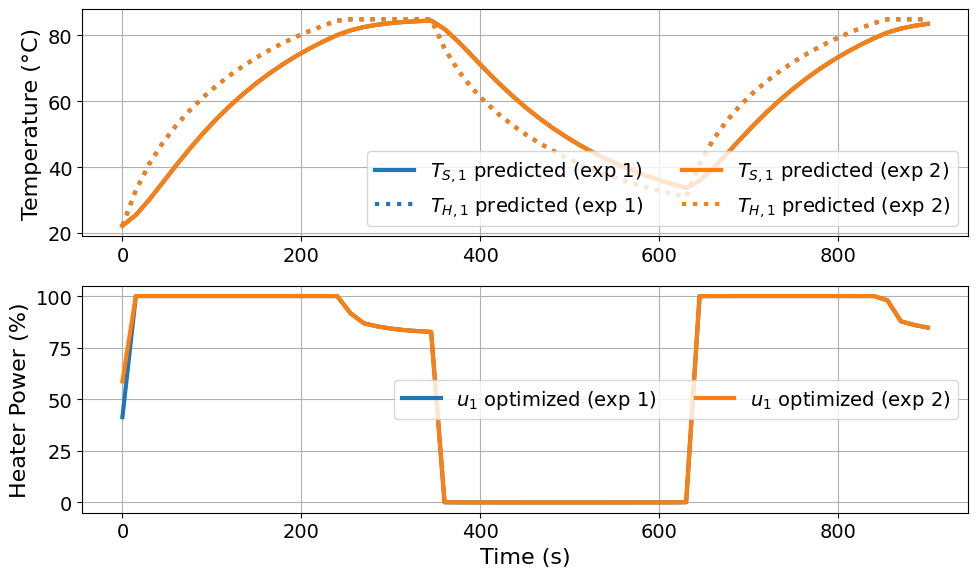

In [7]:
multiexp_results = extract_plot_results(None, TC_Lab_DoE_D)

Interesting! we get a tooth-like step change in the design (heater power). The designs are quite similar in shape although experiment 1 starts at lower power stays longer at 100% power. 

In [8]:
FIM_D = np.asarray(TC_Lab_DoE_D.results["solution"]["param_scenarios"][0]['total_fim'])
if SCALE_BY_NOMINAL_PARAM:
    D = np.diag(theta_ref)
    FIM_D_unscaled = D @ FIM_D @ D
else:
    FIM_D_unscaled = FIM_D
results_summary(np.asarray(FIM_D_unscaled))

======Results Summary======
Five design criteria log10() value:
Pseudo A-optimality: 10.197162365075462
A-optimality: -2.196643155635029
D-optimality: 27.035689637070696
E-optimality: 2.1966823382825775
Modified E-optimality: 7.993372563683056

FIM:
 [[ 4.79223337e+09  1.74744362e+08 -1.73533913e+08 -7.00079755e+09]
 [ 1.74744362e+08  2.76967962e+07 -3.52948501e+07 -3.68979291e+08]
 [-1.73533913e+08 -3.52948501e+07  5.08691915e+07  4.22694130e+08]
 [-7.00079755e+09 -3.68979291e+08  4.22694130e+08  1.08749149e+10]]

eigenvalues:
 [1.54901243e+10 2.53834308e+08 1.57283201e+02 1.75550503e+06]

Eigenvector matrix:
          eigvec_1  eigvec_2  eigvec_3  eigvec_4
Ua        -0.5478    0.7534   -0.3631    0.0235
Ub        -0.0262   -0.2489   -0.4204    0.8721
inv_CpH    0.0291    0.3835    0.7835    0.4880
inv_CpS    0.8357    0.4727   -0.2785    0.0258


Now, we will compare different FIM metrics before and after the experimental design. 

In [9]:
# Create a helper function to compute FIM metrics
def log10_FIM_metric(FIM):
    pseudo_A_opt = np.log10(np.trace(FIM))
    A_opt = np.log10(np.trace(np.linalg.inv(FIM)))
    D_opt = np.log10(np.linalg.det(FIM))
    E_opt = np.log10(np.min(np.linalg.eigvals(FIM)))
    ME_opt = np.log10(np.max(np.linalg.eigvals(FIM)) / np.min(np.linalg.eigvals(FIM)))
    return pseudo_A_opt, A_opt, D_opt, E_opt, ME_opt


In [10]:
import pandas as pd
prior_metrics = log10_FIM_metric(PRIOR_FIM)
optimized_metrics = log10_FIM_metric(FIM_D_unscaled)
metric_names = ["pseudo_A_opt", "A_opt", "D_opt", "E_opt", "ME_opt"]

metrics_df = pd.DataFrame(
    {
        "prior": list(prior_metrics),
        "optimized": list(optimized_metrics),
    },
    index=metric_names,
)
metrics_df.index.name = "metric"

metrics_df.round(2)

,prior,optimized
metric,,
pseudo_A_opt,10.20,10.20
A_opt,5.46,-2.20
D_opt,19.38,27.04
E_opt,-5.48,2.20
ME_opt,15.67,7.99


In [12]:
cov_D = np.linalg.inv(FIM_D_unscaled)
print("Standard deviations using D-optimal design:")
for param, std in zip(theta_values.keys(), np.sqrt(np.diag(cov_D))):
    print(f"{param}: {std:.2e}")

Standard deviations using D-optimal design:
beta_1: 2.90e-02
beta_2: 3.35e-02
beta_3: 6.25e-02
beta_4: 2.22e-02
